# DenoisingUNet — Training Notebook

**Stage 1 OCR | Denoiser pre-processing**

This notebook trains a U-Net style CNN to clean noisy scanned document images using the SimulatedNoisyOffice dataset. Each training sample is a (noisy, clean) image pair.

**Steps:**
1. Install & import dependencies
2. Build the dataset (pair noisy ↔ clean images)
3. Visualise noisy vs clean pairs
4. Build the model
5. Train with MSE + SSIM loss
6. Plot training curves
7. Visual denoising results on test images
8. PSNR / SSIM metrics per noise type (grad requirement)

## 1. Install Dependencies

In [ ]:
%pip install torch torchvision numpy matplotlib Pillow --quiet

## 2. Imports & Config

In [1]:
import os, sys, math, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))
from ocr_service.model import DenoisingUNet

# ── Config ────────────────────────────────────────────────────────────────────
EPOCHS     = 50
BATCH_SIZE = 4
LR         = 1e-4
PATCH_SIZE = 256
VAL_SPLIT  = 0.15

DATA_ROOT  = os.path.abspath("../SimulatedNoisyOffice")
NOISY_DIR  = os.path.join(DATA_ROOT, "simulated_noisy_images_grayscale")
CLEAN_DIR  = os.path.join(DATA_ROOT, "clean_images_grayscale")
MODEL_DIR  = os.path.abspath("../models")
SAVE_PATH  = os.path.join(MODEL_DIR, "denoiser.pth")

os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = ("cuda" if torch.cuda.is_available() else
          "mps"  if torch.backends.mps.is_available() else
          "cpu")
print(f"Device    : {DEVICE}")
print(f"Epochs    : {EPOCHS}  |  Batch : {BATCH_SIZE}  |  LR : {LR}")
print(f"Patch size: {PATCH_SIZE}px")

Device    : mps
Epochs    : 50  |  Batch : 4  |  LR : 0.0001
Patch size: 256px


## 3. Dataset

In [2]:
class NoisyOfficeDataset(Dataset):
    """Pairs FontABC_NoiseD_EE.png  <->  FontABC_Clean_EE.png."""

    def __init__(self, noisy_dir, clean_dir, patch_size=256):
        self.patch_size = patch_size
        self.to_tensor  = transforms.ToTensor()
        self.pairs = []

        for noisy_path in sorted(Path(noisy_dir).glob("*.png")):
            parts      = noisy_path.stem.split("_")   # ['FontLre', 'Noisec', 'TR']
            font_code  = parts[0]
            partition  = parts[2]
            clean_path = Path(clean_dir) / f"{font_code}_Clean_{partition}.png"
            if clean_path.exists():
                self.pairs.append((noisy_path, clean_path))

        print(f"Found {len(self.pairs)} noisy/clean pairs.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        noisy_path, clean_path = self.pairs[idx]
        noisy = Image.open(noisy_path).convert("L")
        clean = Image.open(clean_path).convert("L")
        noisy, clean = self._random_crop(noisy, clean)
        return self.to_tensor(noisy), self.to_tensor(clean)

    def _random_crop(self, noisy, clean):
        w, h = noisy.size
        ps   = self.patch_size
        if w <= ps or h <= ps:
            noisy = noisy.resize((ps+1, ps+1), Image.BILINEAR)
            clean = clean.resize((ps+1, ps+1), Image.BILINEAR)
            w, h  = ps+1, ps+1
        x   = random.randint(0, w - ps)
        y   = random.randint(0, h - ps)
        box = (x, y, x+ps, y+ps)
        return noisy.crop(box), clean.crop(box)


full_ds = NoisyOfficeDataset(NOISY_DIR, CLEAN_DIR, patch_size=PATCH_SIZE)
n_val   = max(1, int(len(full_ds) * VAL_SPLIT))
n_train = len(full_ds) - n_val
train_ds, val_ds = random_split(full_ds, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train: {n_train}  |  Val: {n_val}")

Found 216 noisy/clean pairs.
Train: 184  |  Val: 32


## 4. Visualise Noisy vs Clean Pairs

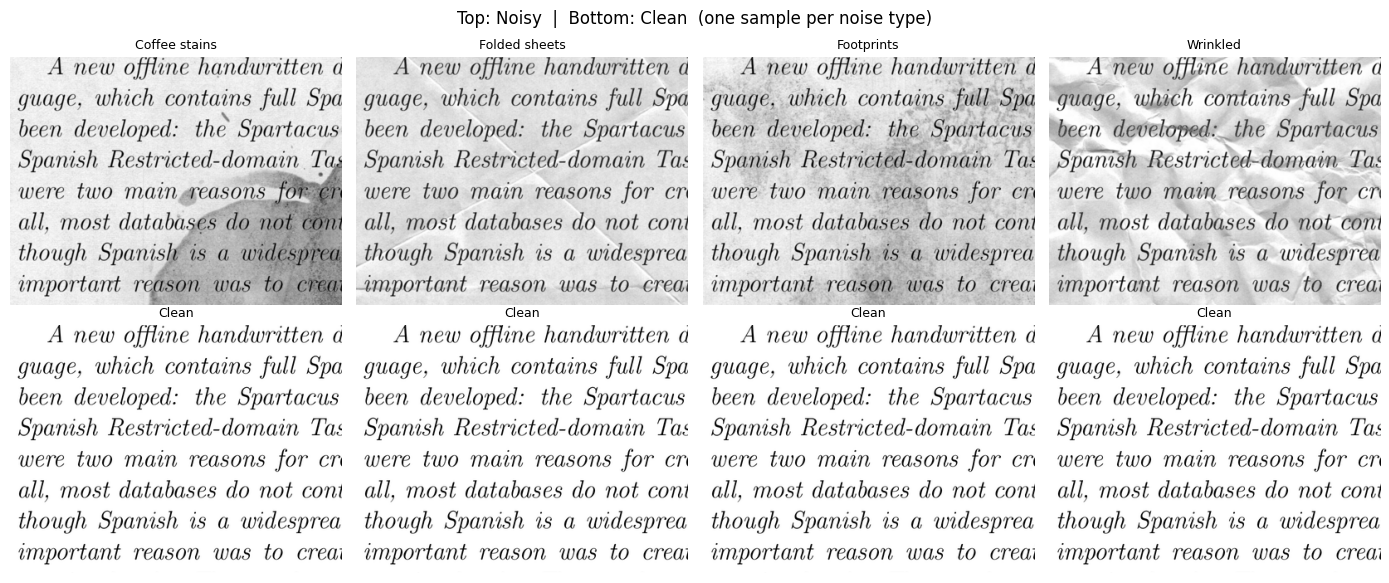

In [3]:
NOISE_NAMES = {"Noisec": "Coffee stains", "Noisef": "Folded sheets",
               "Noisep": "Footprints",    "Noisew": "Wrinkled"}

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Top: Noisy  |  Bottom: Clean  (one sample per noise type)", fontsize=12)

to_tensor = transforms.ToTensor()
seen = set()
col  = 0

for noisy_path, clean_path in full_ds.pairs:
    noise_code = noisy_path.stem.split("_")[1]
    if noise_code in seen or col >= 4:
        continue
    seen.add(noise_code)

    noisy_img = Image.open(noisy_path).convert("L")
    clean_img = Image.open(clean_path).convert("L")
    w, h      = noisy_img.size
    box       = (0, 0, min(400, w), min(300, h))

    axes[0, col].imshow(noisy_img.crop(box), cmap="gray")
    axes[0, col].set_title(NOISE_NAMES.get(noise_code, noise_code), fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(clean_img.crop(box), cmap="gray")
    axes[1, col].set_title("Clean", fontsize=9)
    axes[1, col].axis("off")
    col += 1

plt.tight_layout()
plt.show()

## 5. Build Model & Loss

In [4]:
def ssim_loss(pred, target, window_size=11):
    C1, C2 = 0.01**2, 0.03**2
    mu_x  = F.avg_pool2d(pred,   window_size, 1, window_size//2)
    mu_y  = F.avg_pool2d(target, window_size, 1, window_size//2)
    mu_x2, mu_y2, mu_xy = mu_x**2, mu_y**2, mu_x*mu_y
    sig_x  = F.avg_pool2d(pred**2,    window_size, 1, window_size//2) - mu_x2
    sig_y  = F.avg_pool2d(target**2,  window_size, 1, window_size//2) - mu_y2
    sig_xy = F.avg_pool2d(pred*target, window_size, 1, window_size//2) - mu_xy
    ssim_map = ((2*mu_xy+C1)*(2*sig_xy+C2)) / ((mu_x2+mu_y2+C1)*(sig_x+sig_y+C2))
    return 1.0 - ssim_map.mean()

def combined_loss(pred, target, alpha=0.8):
    return alpha * F.mse_loss(pred, target) + (1-alpha) * ssim_loss(pred, target)


model     = DenoisingUNet(base_ch=32).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=5, factor=0.5
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model      : DenoisingUNet (base_ch=32)")
print(f"Parameters : {total_params:,}")
print(f"Loss       : 0.8 * MSE + 0.2 * SSIM")

Model      : DenoisingUNet (base_ch=32)
Parameters : 1,926,433
Loss       : 0.8 * MSE + 0.2 * SSIM


## 6. Training Loop

In [5]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total = 0.
    for noisy, clean in loader:
        noisy, clean = noisy.to(device), clean.to(device)
        optimizer.zero_grad()
        loss = combined_loss(model(noisy), clean)
        loss.backward()
        optimizer.step()
        total += loss.item() * noisy.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    total = 0.
    for noisy, clean in loader:
        noisy, clean = noisy.to(device), clean.to(device)
        total += combined_loss(model(noisy), clean).item() * noisy.size(0)
    return total / len(loader.dataset)


history      = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    va_loss = validate(model, val_loader, DEVICE)
    scheduler.step(va_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model.state_dict(), SAVE_PATH)
        saved = " ✓ saved"
    else:
        saved = ""

    print(f"Epoch {epoch:03d}/{EPOCHS}  train={tr_loss:.5f}  val={va_loss:.5f}{saved}")

print(f"\nBest val loss : {best_val_loss:.5f}")

Epoch 001/50  train=0.13373  val=0.09323 ✓ saved
Epoch 002/50  train=0.06341  val=0.05624 ✓ saved
Epoch 003/50  train=0.04932  val=0.04427 ✓ saved
Epoch 004/50  train=0.04122  val=0.03883 ✓ saved
Epoch 005/50  train=0.03538  val=0.03317 ✓ saved
Epoch 006/50  train=0.03135  val=0.02936 ✓ saved
Epoch 007/50  train=0.02765  val=0.02630 ✓ saved
Epoch 008/50  train=0.02483  val=0.02392 ✓ saved
Epoch 009/50  train=0.02250  val=0.02114 ✓ saved
Epoch 010/50  train=0.02017  val=0.01935 ✓ saved
Epoch 011/50  train=0.01849  val=0.01804 ✓ saved
Epoch 012/50  train=0.01689  val=0.01613 ✓ saved
Epoch 013/50  train=0.01544  val=0.01484 ✓ saved
Epoch 014/50  train=0.01427  val=0.01404 ✓ saved
Epoch 015/50  train=0.01338  val=0.01300 ✓ saved
Epoch 016/50  train=0.01229  val=0.01167 ✓ saved
Epoch 017/50  train=0.01139  val=0.01105 ✓ saved
Epoch 018/50  train=0.01064  val=0.01020 ✓ saved
Epoch 019/50  train=0.00986  val=0.00968 ✓ saved
Epoch 020/50  train=0.00925  val=0.00927 ✓ saved
Epoch 021/50  train=

## 7. Plot Training Curves

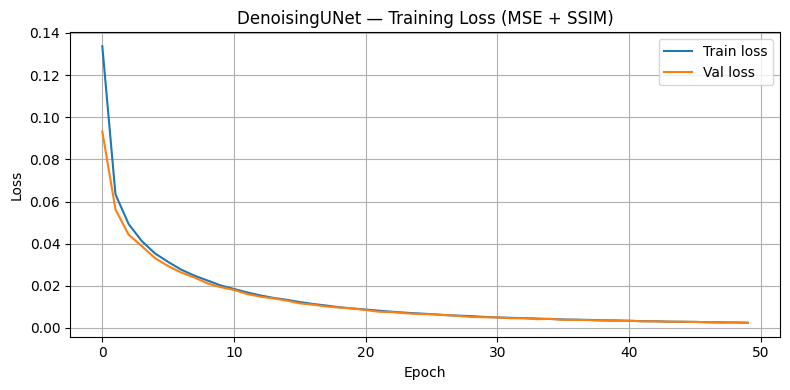

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"],   label="Val loss")
plt.title("DenoisingUNet — Training Loss (MSE + SSIM)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. Visual Denoising Results

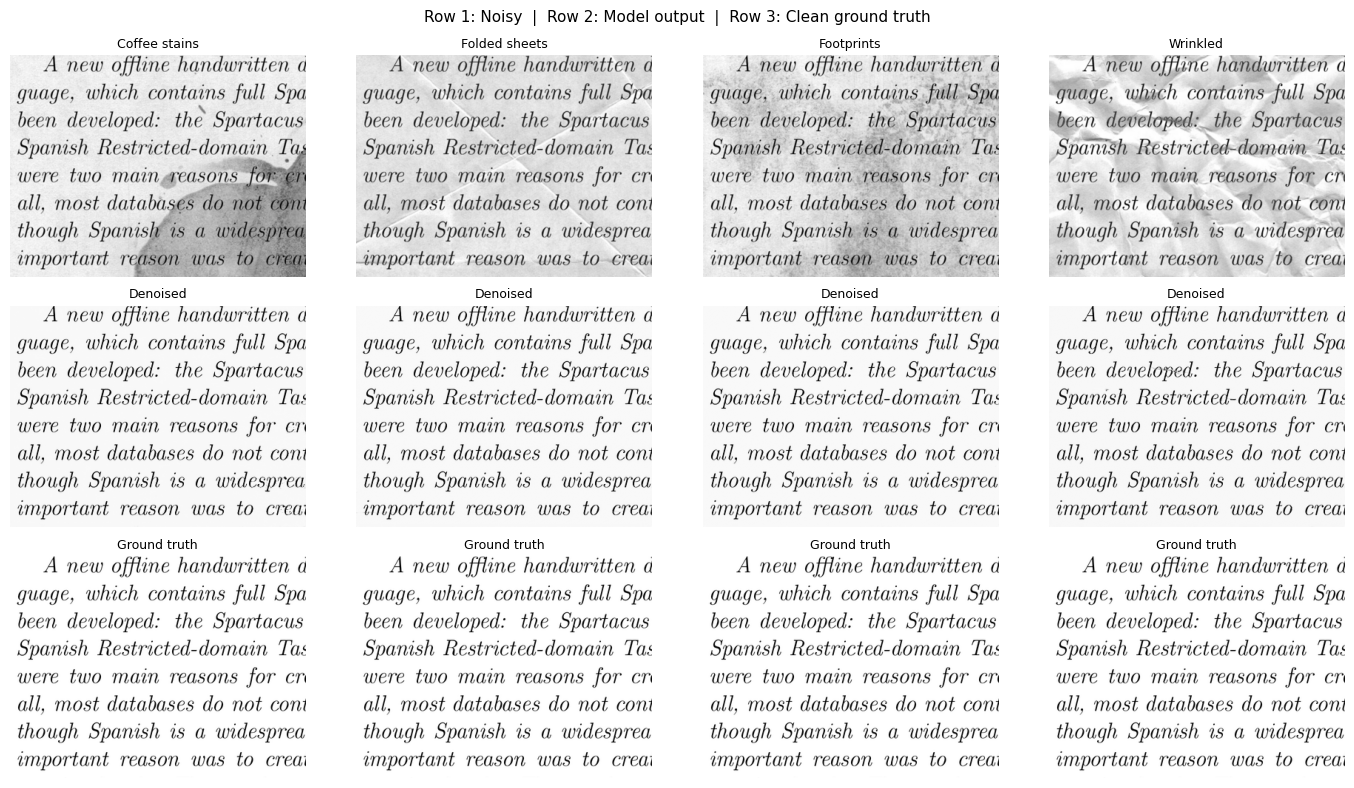

In [7]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

test_pairs = [(p, c) for p, c in full_ds.pairs if "_TE" in p.stem][:4]
to_tensor  = transforms.ToTensor()

fig, axes = plt.subplots(3, len(test_pairs), figsize=(14, 8))
fig.suptitle("Row 1: Noisy  |  Row 2: Model output  |  Row 3: Clean ground truth", fontsize=11)

with torch.no_grad():
    for col, (noisy_path, clean_path) in enumerate(test_pairs):
        noisy_img = Image.open(noisy_path).convert("L")
        clean_img = Image.open(clean_path).convert("L")

        w, h  = noisy_img.size
        box   = (0, 0, min(400, w), min(300, h))
        noisy_crop = noisy_img.crop(box)
        clean_crop = clean_img.crop(box)

        inp  = to_tensor(noisy_crop).unsqueeze(0).to(DEVICE)
        pred = model(inp).squeeze().cpu().numpy()

        noise_label = NOISE_NAMES.get(noisy_path.stem.split("_")[1], "")
        axes[0, col].imshow(noisy_crop, cmap="gray"); axes[0, col].set_title(noise_label, fontsize=9); axes[0, col].axis("off")
        axes[1, col].imshow(pred, cmap="gray");       axes[1, col].set_title("Denoised",  fontsize=9); axes[1, col].axis("off")
        axes[2, col].imshow(clean_crop, cmap="gray"); axes[2, col].set_title("Ground truth", fontsize=9); axes[2, col].axis("off")

plt.tight_layout()
plt.show()

## 9. PSNR & SSIM Per Noise Type (Grad Requirement)

In [9]:
def psnr(pred, target):
    mse = F.mse_loss(pred, target).item()
    return 10 * math.log10(1.0 / mse) if mse > 0 else float("inf")

def ssim_score(pred, target, ws=11):
    C1, C2 = 0.01**2, 0.03**2
    mu_x  = F.avg_pool2d(pred,   ws, 1, ws//2)
    mu_y  = F.avg_pool2d(target, ws, 1, ws//2)
    mu_x2, mu_y2, mu_xy = mu_x**2, mu_y**2, mu_x*mu_y
    sig_x  = F.avg_pool2d(pred**2,     ws, 1, ws//2) - mu_x2
    sig_y  = F.avg_pool2d(target**2,   ws, 1, ws//2) - mu_y2
    sig_xy = F.avg_pool2d(pred*target, ws, 1, ws//2) - mu_xy
    return (((2*mu_xy+C1)*(2*sig_xy+C2)) / ((mu_x2+mu_y2+C1)*(sig_x+sig_y+C2))).mean().item()


noise_metrics = {}
all_psnr, all_ssim = [], []

with torch.no_grad():
    for noisy_path, clean_path in full_ds.pairs:
        if "_TE" not in noisy_path.stem:
            continue
        noise_code = noisy_path.stem.split("_")[1]

        noisy_t = to_tensor(Image.open(noisy_path).convert("L")).unsqueeze(0).to(DEVICE)
        clean_t = to_tensor(Image.open(clean_path).convert("L")).unsqueeze(0).to(DEVICE)
        pred    = model(noisy_t)

        p = psnr(pred, clean_t)
        s = ssim_score(pred, clean_t)
        all_psnr.append(p); all_ssim.append(s)

        if noise_code not in noise_metrics:
            noise_metrics[noise_code] = {"psnr": [], "ssim": []}
        noise_metrics[noise_code]["psnr"].append(p)
        noise_metrics[noise_code]["ssim"].append(s)

print(f"{'Noise type':<22}  {'PSNR (dB)':>10}  {'SSIM':>8}")
print("-" * 45)
for code, vals in sorted(noise_metrics.items()):
    name = NOISE_NAMES.get(code, code)
    print(f"{name:<22}  {np.mean(vals['psnr']):>10.2f}  {np.mean(vals['ssim']):>8.4f}")
print("-" * 45)
print(f"{'Overall':<22}  {np.mean(all_psnr):>10.2f}  {np.mean(all_ssim):>8.4f}")

Noise type               PSNR (dB)      SSIM
---------------------------------------------
Coffee stains                27.40    0.9905
Folded sheets                28.37    0.9953
Footprints                   28.08    0.9941
Wrinkled                     27.76    0.9935
---------------------------------------------
Overall                      27.90    0.9933
